In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import callbacks
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D
from tensorflow.keras.metrics import Precision, Recall

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

2024-03-15 18:23:10.669096: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-15 18:23:10.669223: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-15 18:23:10.831498: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
train_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_dir = "/kaggle/input/brain-tumor-mri-dataset/Testing"

resize_size = (240,240)

batch_size = 32

In [4]:
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = test_dir ,
    image_size = resize_size ,
    label_mode = "categorical" ,
    batch_size = batch_size ,
    )

# Define classes names
class_names = test_data.class_names
print("Class names:", class_names)

Found 1311 files belonging to 4 classes.
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [5]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory=train_dir,
    image_size=resize_size,
    label_mode="categorical",
    batch_size=batch_size,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=123
)


#validation dataset
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory=train_dir,
    image_size=resize_size,
    label_mode="categorical",
    batch_size=batch_size,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=123
)

Found 5712 files belonging to 4 classes.
Using 4570 files for training.
Found 5712 files belonging to 4 classes.
Using 1142 files for validation.


In [6]:
def showSampleImages(data):
    class_names=data.class_names
    plt.figure(figsize=(12, 12))
    for images,labels in data.take(1):
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[tf.argmax(labels[i])])
            plt.axis("off")

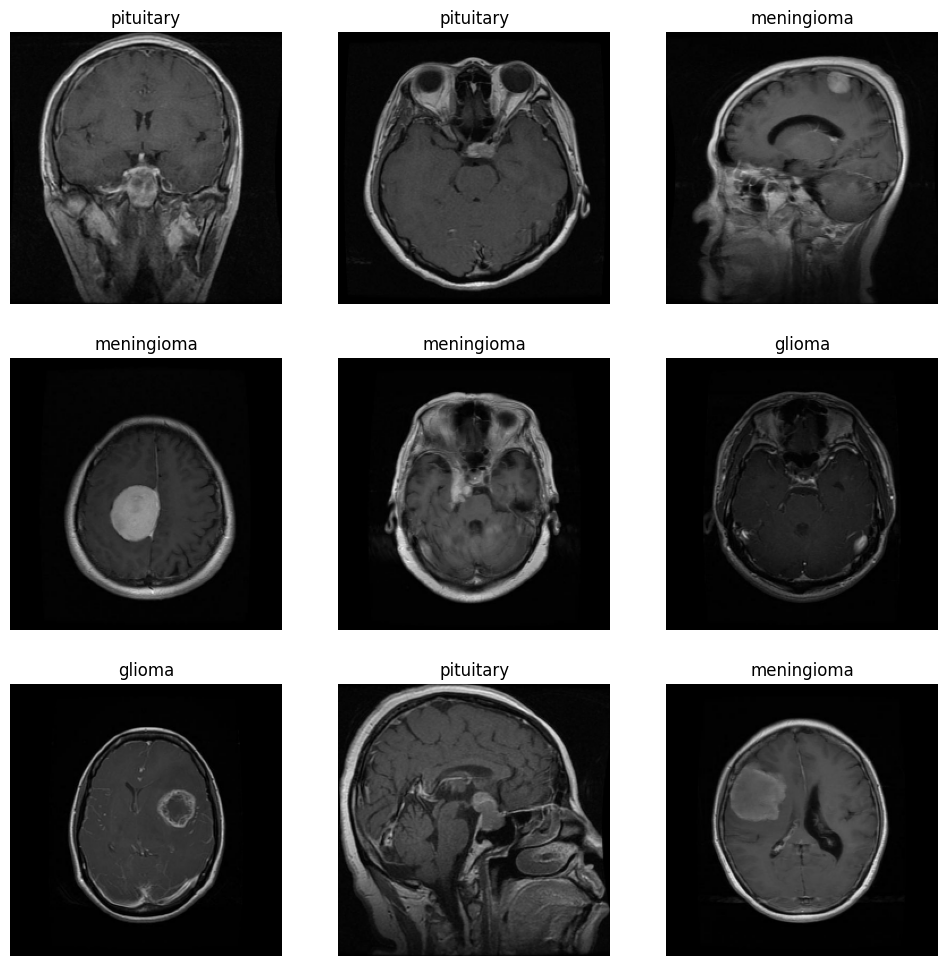

In [7]:
showSampleImages(train_data)


# Ckecking Count of data

In [8]:
def print_count_and_bar_graph(data,data_name,pallete_style="deep"):
    class_names=data.class_names
    ds=pd.DataFrame({'Class':class_names,'Count':len(class_names)*[0]})
    
    #Looping over the data
    for images,labels in data:
        for i in range(len(images)):
            for category in class_names:
                if class_names[tf.argmax(labels[i])]==category:
                    ds.loc[ds['Class']==category,'Count']+=1
    #print count
    for category in class_names:
        print(f"{category} : {ds.loc[ds['Class']==category,'Count']}")

    #print bar plot
    plt.figure(figsize=(12,7))
    ax = sns.barplot(data=ds , x='Class',y='Count', palette=pallete_style)
    sns.set(style="dark",palette="colorblind")
    plt.title('Count of images in each class of '+data_name, fontsize=20)
    ax.bar_label(ax.containers[0])
    plt.show()


glioma : 0    1090
Name: Count, dtype: int64
meningioma : 1    1042
Name: Count, dtype: int64
notumor : 2    1274
Name: Count, dtype: int64
pituitary : 3    1164
Name: Count, dtype: int64


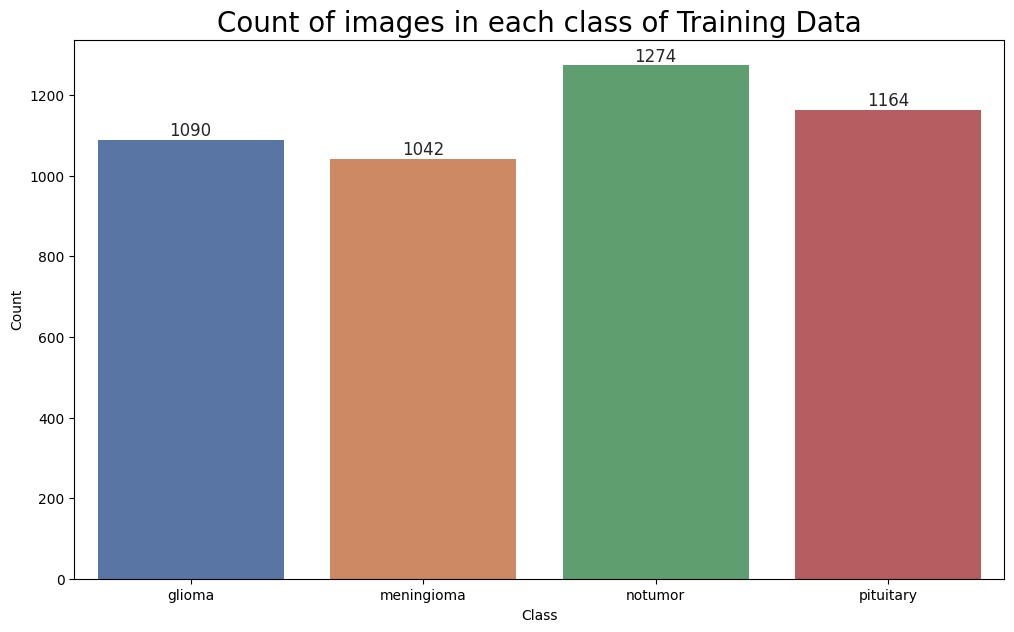

In [9]:
print_count_and_bar_graph(train_data,"Training Data")

glioma : 0    1090
Name: Count, dtype: int64
meningioma : 1    1042
Name: Count, dtype: int64
notumor : 2    1274
Name: Count, dtype: int64
pituitary : 3    1164
Name: Count, dtype: int64


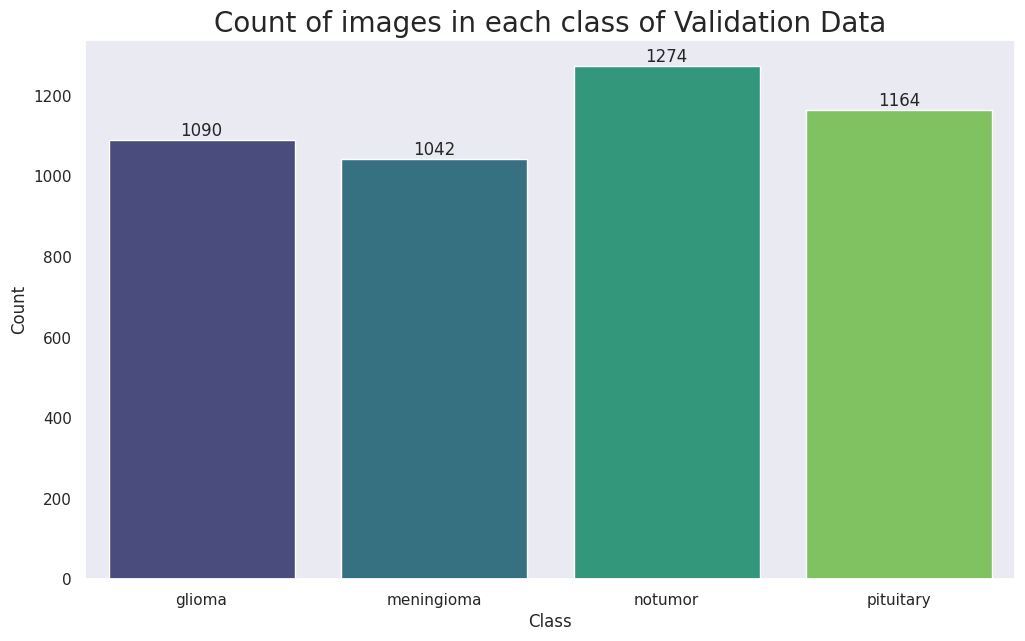

In [10]:
print_count_and_bar_graph(train_data,"Validation Data",pallete_style="viridis")

glioma : 0    300
Name: Count, dtype: int64
meningioma : 1    306
Name: Count, dtype: int64
notumor : 2    405
Name: Count, dtype: int64
pituitary : 3    300
Name: Count, dtype: int64


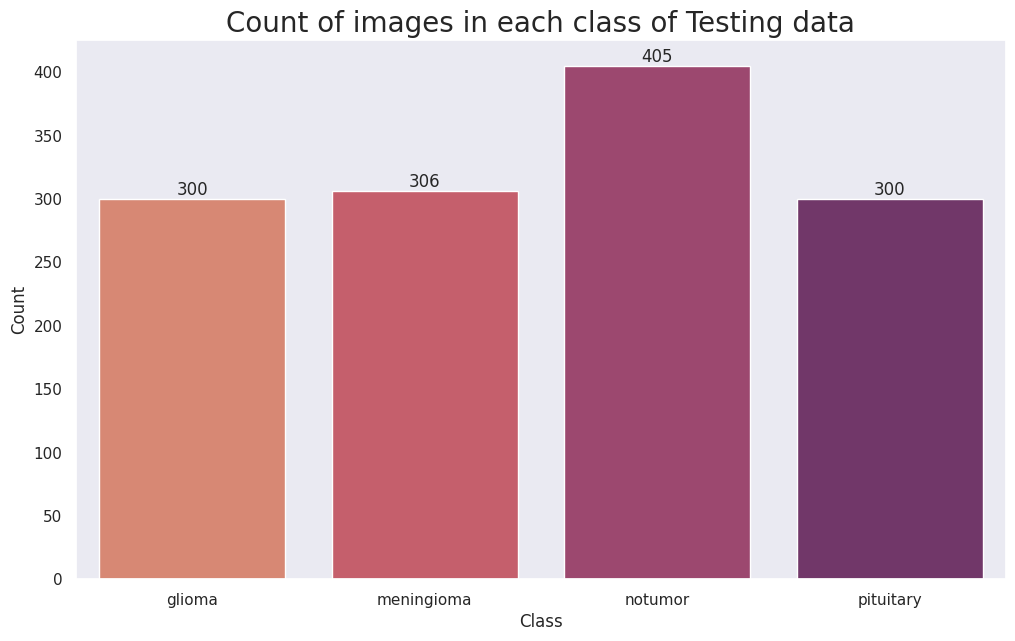

In [11]:
print_count_and_bar_graph(test_data,"Testing data",pallete_style="flare")

In [12]:
img_shape=(240,240,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [13]:
base_model.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 119, 119,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 119, 119,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 119, 119,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 117, 117,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 117, 117,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 117, 117,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 117, 117,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 117, 117,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 117, 117,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 117, 117,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 117, 117,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 59, 59,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 59, 59,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 59, 59,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 59, 59,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 59, 59,    │          0 │ add[0][0]       

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 20,806,952 (79.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall

In [29]:
from tensorflow.keras.models import Model

In [46]:
x=base_model.output
x=Dropout(rate= 0.3)(x)
x=Dense(128, activation= 'relu')(x)
x=Dropout(rate= 0.25)(x)
x =Dense(4, activation="softmax")(x)

model = Model(base_model.input, x)


In [47]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 119, 119,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 119, 119,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 119, 119,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 117, 117,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 117, 117,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 117, 117,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 117, 117,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 117, 117,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 117, 117,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 117, 117,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 117, 117,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 59, 59,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 59, 59,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 59, 59,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 59, 59,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 59, 59,    │          0 │ add[0][0]       

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [49]:
callback_list=[
    callbacks.EarlyStopping(monitor="val_accuracy",patience=3,restore_best_weights=True),
    callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True),
    callbacks.ReduceLROnPlateau(factor=0.8,monitor="val_accuracy",patience=3)
]

In [50]:
 model.compile(loss = "categorical_crossentropy", 
                  optimizer = Adamax(learning_rate= 0.001),
                  metrics=['accuracy', Precision(), Recall()])
    

In [51]:
Model_History= model.fit(train_data,
                 epochs=10,
                 validation_data=val_data,
                 verbose = 1 ,
                 callbacks = callback_list,
                 shuffle= False)

Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 111s 484ms/step - accuracy: 0.9558 - loss: 0.1409 - precision_3: 0.9643 - recall_3: 0.9423 - val_accuracy: 0.9764 - val_loss: 0.1014 - val_precision_3: 0.9764 - val_recall_3: 0.9764 - learning_rate: 0.0010
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 99s 321ms/step - accuracy: 0.9932 - loss: 0.0198 - precision_3: 0.9936 - recall_3: 0.9926 - val_accuracy: 0.9527 - val_loss: 0.1972 - val_precision_3: 0.9527 - val_recall_3: 0.9527 - learning_rate: 0.0010
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 46s 320ms/step - accuracy: 0.9931 - loss: 0.0247 - precision_3: 0.9936 - recall_3: 0.9921 - val_accuracy: 0.9729 - val_loss: 0.1206 - val_precision_3: 0.9729 - val_recall_3: 0.9729 - learning_rate: 0.0010
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 46s 322ms/step - accuracy: 0.9983 - loss: 0.0073 - precision_3: 0.9983 - recall_3: 0.9983 - val_accuracy: 0.9807 - val_loss: 0.0938 - val_precision_3: 0.9807 - val_recall_3: 0.9807 - learning_rate: 0.0010
Epoch 5/10
143/143 

In [55]:
def plot_metrices_graphs(Model_History, start=0):
    metrices = {
        "train_Loss": Model_History.history['loss'],
        "val_Loss": Model_History.history['val_loss'],
        "train_Accuracy": Model_History.history['accuracy'],
        "val_Accuracy": Model_History.history['val_accuracy'],
        "train_Precision": Model_History.history['precision_3'],
        "val_Precision": Model_History.history['val_precision_3'],
        "train_Recall": Model_History.history['recall_3'],
        "val_Recall": Model_History.history['val_recall_3']
    }

    bestEpoch = {
        "Loss": np.argmin(metrices["val_Loss"]),
        "Accuracy": np.argmax(metrices["val_Accuracy"]),
        "Precision": np.argmax(metrices["val_Precision"]),
        "Recall": np.argmax(metrices["val_Recall"])
    }

    Epochs = [i + 1 for i in range(start, len(metrices['train_Accuracy']))]

    plt.figure(figsize=(20, 12))
    plt.style.use('fivethirtyeight')

    i = 0
    for j in range(0, 4):
        plt.subplot(2, 2, j+1)
        plt.plot(Epochs, metrices["train_" + list(bestEpoch.keys())[j]], 'r', label=f'Training {list(bestEpoch.keys())[j]}')
        plt.plot(Epochs, metrices["val_" + list(bestEpoch.keys())[j]], 'g', label=f'Validation {list(bestEpoch.keys())[j]}')
        plt.scatter(bestEpoch[list(bestEpoch.keys())[j]], metrices["val_" + list(bestEpoch.keys())[j]][bestEpoch[list(bestEpoch.keys())[j]]], s=150, c='blue', label=f'Best Epoch = {bestEpoch[list(bestEpoch.keys())[j]]}')
        plt.title(f'Training and Validation {list(bestEpoch.keys())[j]}')
        plt.xlabel('Epochs')
        plt.ylabel(f'{list(bestEpoch.keys())[j]}')
        plt.legend()
        plt.grid(True)
        i += 1

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    plt.show()


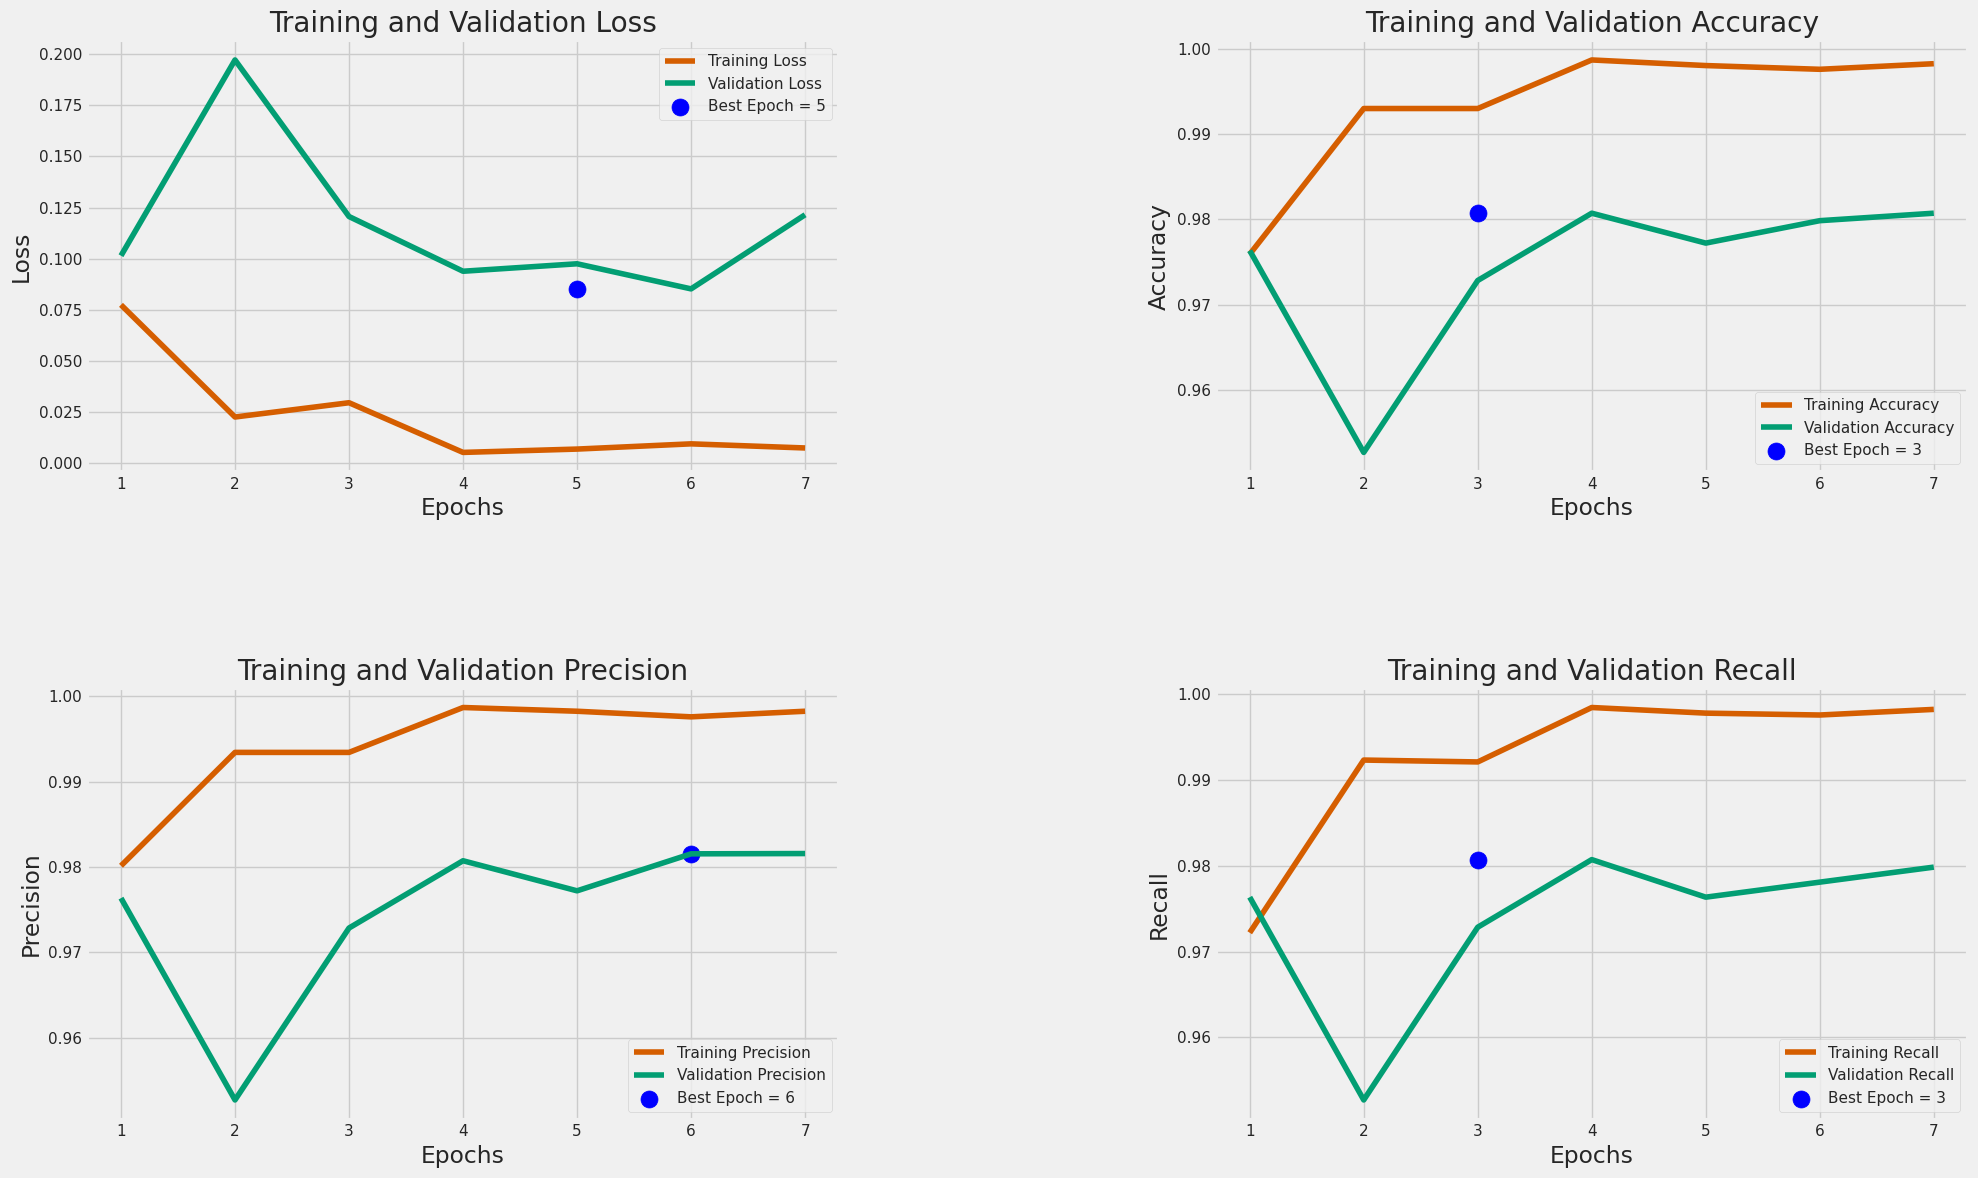

In [56]:
plot_metrices_graphs(Model_History)

In [57]:
def Evaluate_Model(model,train_data,test_data):
    train_score = model.evaluate(train_data, verbose=1)
    test_score = model.evaluate(test_data,verbose=1)

    print(f"Train Loss: {train_score[0]:.4f}")
    print(f"Train Accuracy: {train_score[1]*100:.2f}%")
    print('-' * 30)
    print(f"Test Loss: {test_score[0]:.4f}")
    print(f"Test Accuracy: {test_score[1]*100:.2f}%")

In [58]:
Evaluate_Model(model,train_data,test_data)

143/143 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - accuracy: 0.9978 - loss: 0.0076 - precision_3: 0.9980 - recall_3: 0.9976
41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 296ms/step - accuracy: 0.9879 - loss: 0.0568 - precision_3: 0.9884 - recall_3: 0.9834
Train Loss: 0.0096
Train Accuracy: 99.69%
------------------------------
Test Loss: 0.0653
Test Accuracy: 98.32%


In [59]:
from sklearn.metrics import classification_report, confusion_matrix

def printClassificationReportAndConfusionMaxtrix(model, class_names, data):
    true_labels = []
    predicted_labels = []

    for images, labels in data:
        true_labels.extend(np.argmax(labels.numpy(),axis=1))  # Convert one-hot encoded labels to class indices
        predicted_labels.extend(np.argmax(model.predict(images),axis=1))  # Obtain model predictions

    # Print classification report
    print("\n" * 5)
    print(classification_report(true_labels, predicted_labels, target_names=class_names))
    print("\n" * 5)

    # Compute the confusion matrix
    conf_matrix = confusion_matrix(true_labels, predicted_labels)

    # Plot the confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━

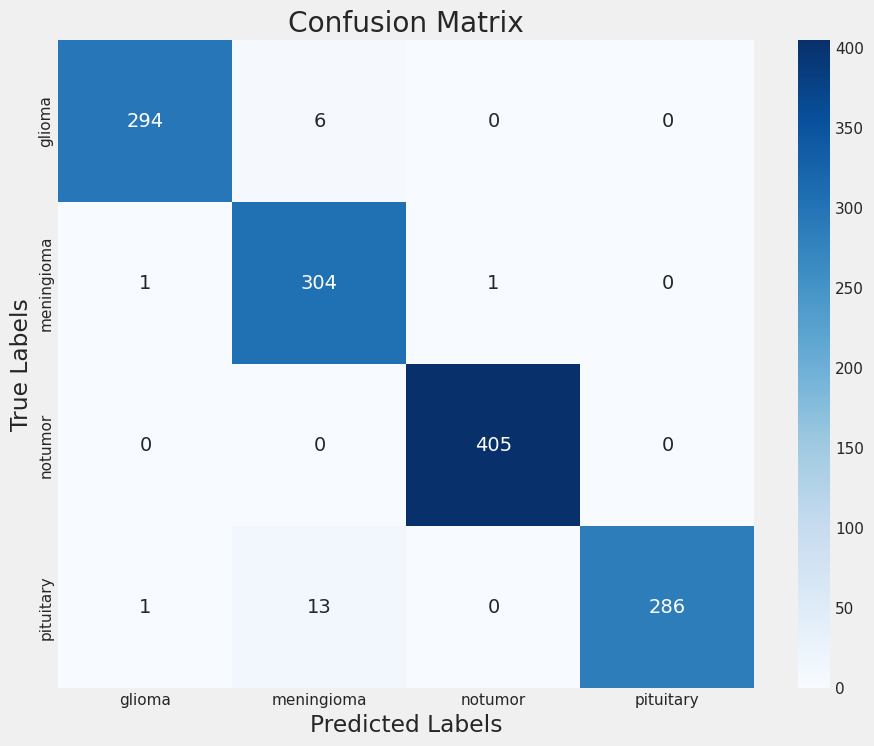

In [60]:
printClassificationReportAndConfusionMaxtrix(model,class_names,test_data)

In [71]:
model.save("tumor_xception.h5")

In [66]:
import cv2
from PIL import Image
import scipy  #Used to upsample our image
from matplotlib.patches import Rectangle #To add a rectangle overlay to the image
from skimage.feature.peak import peak_local_max  #To detect hotspots in 2D images. 

In [63]:
def getImage(img_path):
    image = cv2.imread(img_path)
    image = Image.fromarray(image, 'RGB')
    image = image.resize(resize_size)
    image = np.array(image)
    return image

In [64]:
def showPredictionStatistics(img_path,class_names=class_names,size=resize_size):
    plt.figure(figsize=(6, 6))
    img=getImage(img_path)
    predictions = model.predict(np.expand_dims(img, axis=0))
    probs = list(predictions[0]*100)
    print(probs)
    labels = class_names
    plt.subplot(2, 1, 1)
    plt.imshow(img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Percentage', fontsize=20)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
[1.7706141e-07, 1.3048453e-06, 2.4006415e-06, 100.0]


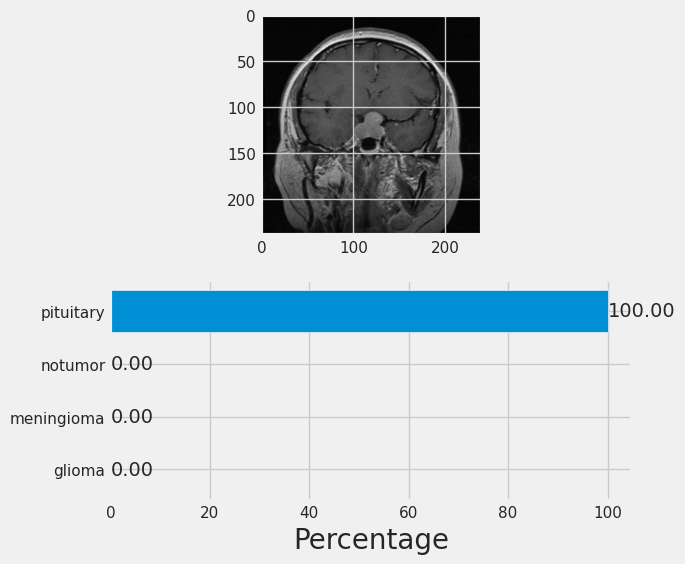

In [67]:
showPredictionStatistics('/kaggle/input/brain-tumor-mri-dataset/Testing/pituitary/Te-piTr_0001.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[5.4338795e-10, 6.131264e-08, 100.0, 4.9076547e-08]


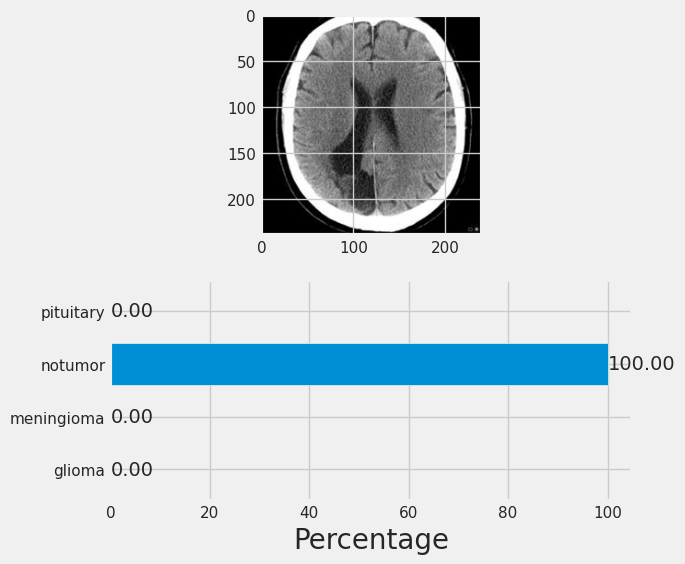

In [68]:
showPredictionStatistics('/kaggle/input/brain-tumor-mri-dataset/Testing/notumor/Te-noTr_0009.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[99.940254, 0.017597595, 0.0033186271, 0.038824983]


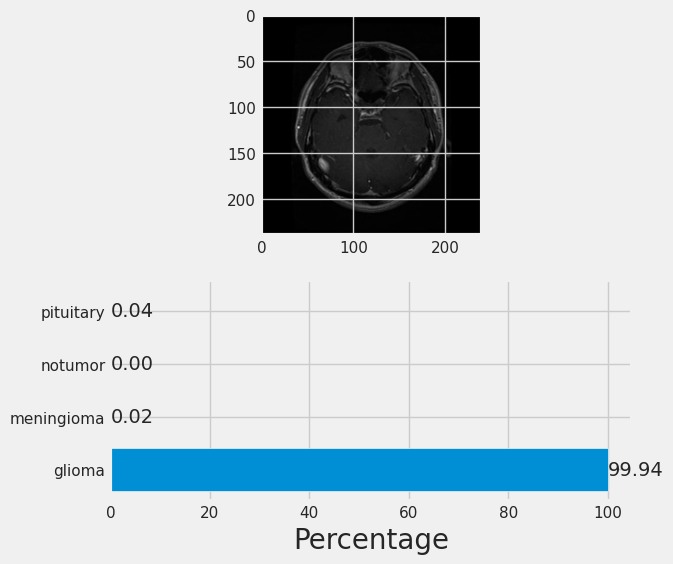

In [69]:
showPredictionStatistics('/kaggle/input/brain-tumor-mri-dataset/Testing/glioma/Te-gl_0012.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
[8.813448e-06, 99.99981, 0.00012682225, 5.5223074e-05]


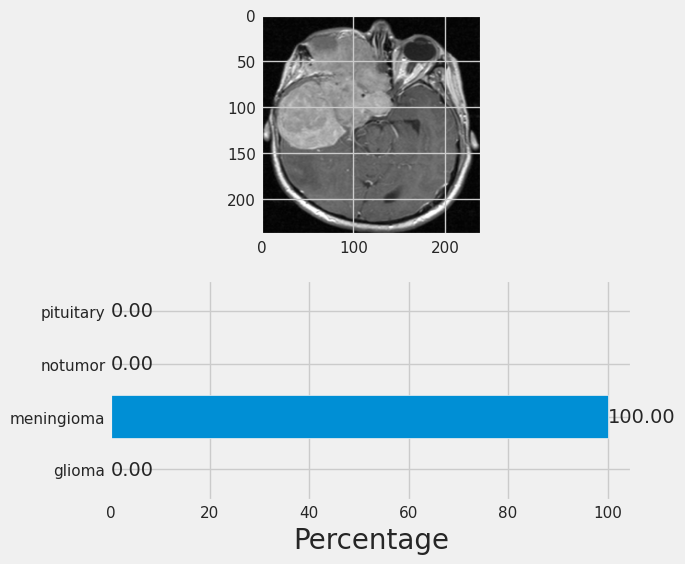

In [72]:
showPredictionStatistics('/kaggle/input/brain-tumor-mri-dataset/Testing/meningioma/Te-me_0018.jpg')